In [5]:
import xgboost as xgb
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [4]:
# Load your dataset
descriptor_path = "../DATA/molecular_descriptors_concat_data_product2_Target-cmc.csv"  # Change this to your actual file path
df_descriptors = pd.read_csv(descriptor_path)

cluster_path = "../RESULTS/2025-03-06_12-55-55-cmc/cluster_labels.csv"  # Change this to your actual file path
df_cluster = pd.read_csv(cluster_path)

In [6]:
df_descriptors.columns

Index(['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES', 'MW', 'LogP', 'TPSA',
       'HBA', 'HBD', 'RotBonds', 'NumAromRings', 'FractionCSP3', 'NumRings',
       'HeavyAtomCount', 'CarbonCount', 'AliphaticCarbonCount', 'NumOH',
       'NumCarbonyls', 'NumCarboxyls', 'NumEthers', 'NumSulfurs', 'NumAmines',
       'LabuteASA', 'NumChargedAtoms', 'MolMR', 'LongestAliphaticChain',
       'PolarRatio', 'Chi0v', 'Chi1v'],
      dtype='object')

In [7]:
df_cluster.columns

Index(['Cluster Labels'], dtype='object')

In [9]:
# Define features and target
# df_drop = ['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES']  # Change this to your target column
X = df_descriptors.drop(columns=['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES'])
y = df_cluster['Cluster Labels']

In [10]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [11]:
# Check if it's binary or multi-class classification
num_classes = len(np.unique(y))
if num_classes == 2:
    objective = "binary:logistic"  # Binary classification
else:
    objective = "multi:softmax"  # Multi-class classification
    num_classes = len(np.unique(y))  # Get the number of unique classes

In [12]:
# Train XGBoost model
model = xgb.XGBClassifier(objective=objective, num_class=num_classes if num_classes > 2 else None, 
                          n_estimators=100, random_state=42)
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None, num_class=5,
              num_parallel_tree=None, ...)

In [13]:
# Predictions and Accuracy
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9524


In [26]:
# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

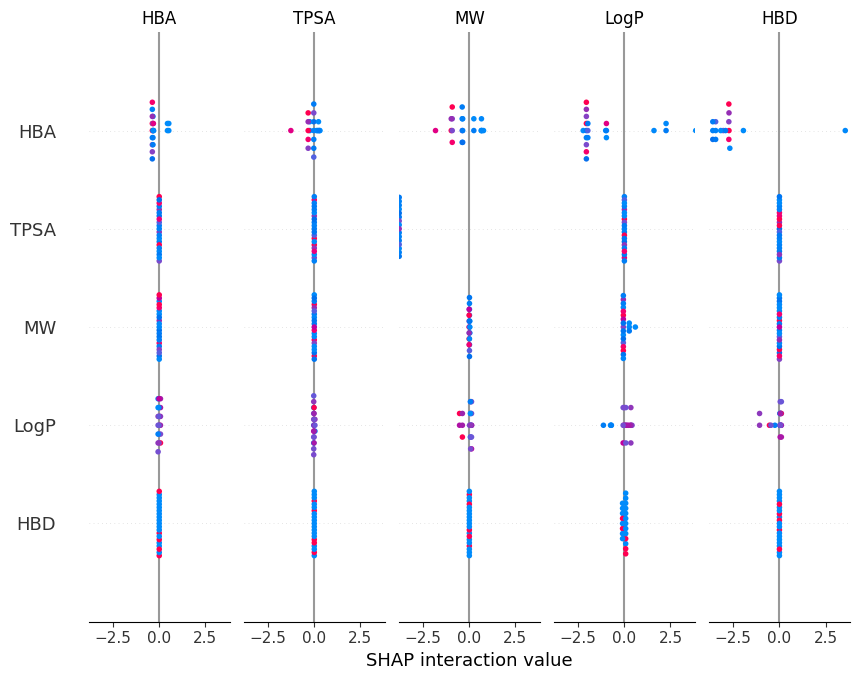

In [27]:
# For binary classification: Take SHAP values of the positive class (index 1)
if num_classes == 2:
    shap.summary_plot(shap_values[:, 1], X_test)
else:
    # For multi-class classification: Aggregate SHAP values
    shap.summary_plot(shap_values, X_test)

SHAP values shape before aggregation: (21, 25, 5)
SHAP values shape after aggregation: (21, 25)
X_test shape: (21, 25)


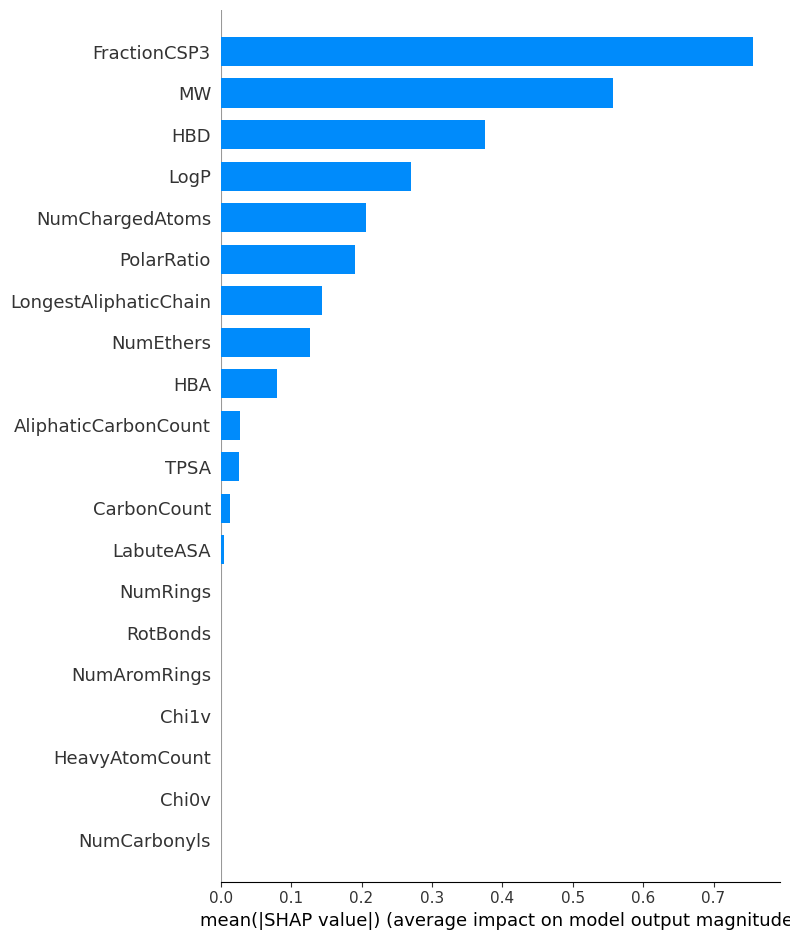

In [40]:
# Compute SHAP values
explainer = shap.Explainer(model)
shap_values = explainer.shap_values(X_test)

# Check shape before aggregation
print("SHAP values shape before aggregation:", np.array(shap_values).shape)

# Aggregate across classes (axis=0) to keep all 25 features
shap_values_mean = np.mean(np.abs(shap_values), axis=2)  # Aggregates across classes, keeps (21, 25)

# Check shape after fixing aggregation
print("SHAP values shape after aggregation:", shap_values_mean.shape)
print("X_test shape:", X_test.shape)

# Ensure the shapes match before plotting
assert shap_values_mean.shape == X_test.shape, "Shape mismatch! Check feature selection."

# Now the SHAP summary plot should work correctly
shap.summary_plot(shap_values_mean, X_test, plot_type="bar")


SHAP values shape before aggregation: (21, 25, 5)
SHAP values shape after aggregation: (21, 25)
X_test shape: (21, 25)


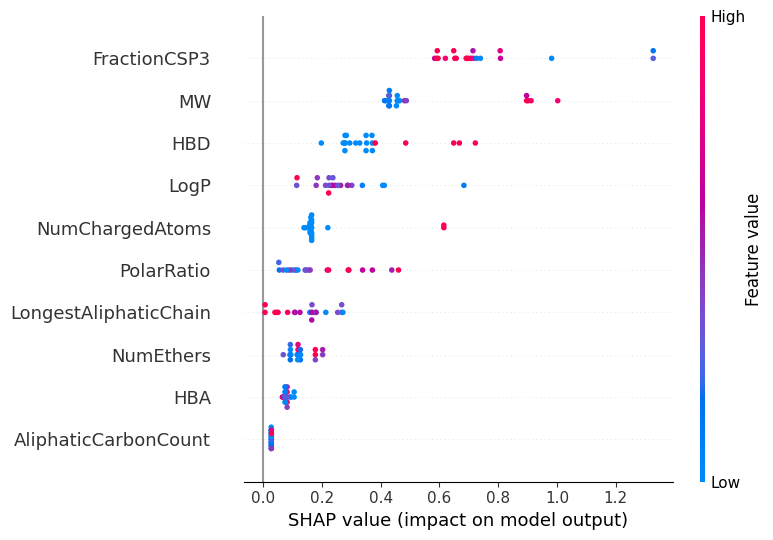

In [41]:
# Compute SHAP values
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Check shape before aggregation
print("SHAP values shape before aggregation:", np.array(shap_values).shape)

# Aggregate across classes (axis=0) to keep all 25 features
shap_values_mean = np.mean(np.abs(shap_values), axis=2)  # Aggregates across classes, keeps (21, 25)

# Check shape after fixing aggregation
print("SHAP values shape after aggregation:", shap_values_mean.shape)
print("X_test shape:", X_test.shape)

# Ensure the shapes match before plotting
assert shap_values_mean.shape == X_test.shape, "Shape mismatch! Check feature selection."

# Now the SHAP summary plot should work correctly
shap.summary_plot(shap_values_mean, X_test, max_display=10)  # Show only the top 10 features


---------------------------------------------------------------------------------------
# Random Forest

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import seaborn as sns

In [42]:
# Load your dataset (you already have this)
descriptor_path = "../DATA/molecular_descriptors_concat_data_product2_Target-cmc.csv"
df_descriptors = pd.read_csv(descriptor_path)
cluster_path = "../RESULTS/2025-03-06_12-55-55-cmc/cluster_labels.csv"
df_cluster = pd.read_csv(cluster_path)

X = df_descriptors.drop(columns=['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES'])
y = df_cluster['Cluster Labels']

In [44]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a model (RandomForest works well with SHAP)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [45]:
# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.9375


In [53]:
# Get number of clusters
num_clusters = len(np.unique(y))
print(f"Number of clusters: {num_clusters}")

Number of clusters: 5


In [54]:
# Use a simpler approach with Permutation Feature Importance first
# This is more reliable and faster than SHAP for initial analysis
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10, 
    random_state=42
)

# Get the importance scores
importance = result.importances_mean
sorted_idx = np.argsort(importance)[::-1]

# Create a DataFrame of the feature importances
perm_importance_df = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance': importance[sorted_idx]
})

# Print the top 20 features
print("\nTop 20 Most Important Features (Permutation Importance):")
print(perm_importance_df.head(20))

# Save to CSV
perm_importance_df.to_csv("descriptor_importance_permutation.csv", index=False)

# Plot the top 15 features
plt.figure(figsize=(10, 8))
plt.barh(range(15), importance[sorted_idx][:15], align='center')
plt.yticks(range(15), X.columns[sorted_idx][:15])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Features (Permutation Importance)')
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=300)
plt.close()



Top 20 Most Important Features (Permutation Importance):
                  Feature  Importance
0                     HBD    0.053125
1                    LogP    0.034375
2         NumChargedAtoms    0.031250
3            FractionCSP3    0.031250
4                   NumOH    0.006250
5   LongestAliphaticChain    0.003125
6             CarbonCount    0.000000
7                    TPSA    0.000000
8                     HBA    0.000000
9                RotBonds    0.000000
10           NumAromRings    0.000000
11               NumRings    0.000000
12         HeavyAtomCount    0.000000
13                  Chi1v    0.000000
14   AliphaticCarbonCount    0.000000
15                  Chi0v    0.000000
16           NumCarbonyls    0.000000
17           NumCarboxyls    0.000000
18              NumEthers    0.000000
19             NumSulfurs    0.000000


In [57]:
# Plot the top 15 features
plt.figure(figsize=(10, 8))
plt.barh(range(15), importance[sorted_idx][:15], align='center')
plt.yticks(range(15), X.columns[sorted_idx][:15])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Features (Permutation Importance)')
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=300)
plt.close()

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap

# Load your dataset
descriptor_path = "../DATA/molecular_descriptors_concat_data_product2_Target-cmc.csv"
df_descriptors = pd.read_csv(descriptor_path)
cluster_path = "../RESULTS/2025-03-06_12-55-55-cmc/cluster_labels.csv"
df_cluster = pd.read_csv(cluster_path)

X = df_descriptors.drop(columns=['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES'])
y = df_cluster['Cluster Labels']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

# Get number of clusters
num_clusters = len(np.unique(y))
print(f"Number of clusters: {num_clusters}")

# Use Permutation Feature Importance - reliable and fast
result = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10, 
    random_state=42
)

# Get the importance scores
importance = result.importances_mean
# sorted_idx = np.argsort(importance)[::-1]
sorted_idx = np.argsort(importance)  # This sorts in ascending order

# Create a DataFrame of the feature importances
perm_importance_df = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance': importance[sorted_idx]
})

# Print the top 20 features
print("\nTop 20 Most Important Features (Permutation Importance):")
print(perm_importance_df.head(20))

# Save to CSV
perm_importance_df.to_csv("descriptor_importance_permutation.csv", index=False)


# Plot in descending order (highest at top)
plt.figure(figsize=(10, 8))
# Take the top 15 features and reverse the order for plotting
n_features = 15
n_features = 15
features_to_plot = perm_importance_df.iloc[-n_features:]  # Get the last n (highest) values
features_to_plot = features_to_plot.iloc[::-1] 

# Create the horizontal bar plot
plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Features (Permutation Importance)')
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=300)
plt.close()
# plt.figure(figsize=(10, 8))
# plt.barh(range(15), importance[sorted_idx][:15], align='center')
# plt.yticks(range(15), X.columns[sorted_idx][:15])
# plt.xlabel('Permutation Importance')
# plt.title('Top 15 Features (Permutation Importance)')
# plt.tight_layout()
# plt.savefig("permutation_importance.png", dpi=300)
# plt.close()

# Try SHAP in a different way - use TreeExplainer with a single tree model
try:
    print("\nAttempting SHAP analysis with a more reliable approach...")
    
    # Create a simple decision tree for each cluster (one-vs-rest)
    from sklearn.tree import DecisionTreeClassifier
    
    # Get top features from permutation importance to focus analysis
    top_n_features = 10
    top_features = perm_importance_df['Feature'].head(top_n_features).tolist()
    X_top = X[top_features]
    X_train_top = X_train[top_features]
    X_test_top = X_test[top_features]
    
    # Store SHAP values for each cluster
    all_shap_values = []
    
    # For each cluster, create a binary classifier and analyze with SHAP
    for i in range(num_clusters):
        print(f"Analyzing cluster {i}...")
        
        # Create binary target (this cluster vs the rest)
        y_train_binary = (y_train == i).astype(int)
        
        # Train a simple decision tree (much easier for SHAP to analyze)
        tree_model = DecisionTreeClassifier(max_depth=5, random_state=42)
        tree_model.fit(X_train_top, y_train_binary)
        
        # Create SHAP explainer
        explainer = shap.TreeExplainer(tree_model)
        
        # Calculate SHAP values on test data
        shap_values = explainer.shap_values(X_test_top)
        
        # If shap_values is a list, take the appropriate component (for binary classification)
        if isinstance(shap_values, list) and len(shap_values) > 1:
            shap_values = shap_values[1]  # Values for the positive class
        
        # Store the SHAP values
        all_shap_values.append(shap_values)
        
        # Create summary plot for this cluster
        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_test_top, plot_type="bar", show=False)
        plt.title(f"Feature Importance for Cluster {i}")
        plt.tight_layout()
        plt.savefig(f"shap_importance_cluster_{i}.png", dpi=300)
        plt.close()
    
    # Create a combined DataFrame of SHAP values across all clusters
    combined_importance = np.zeros(len(top_features))
    for i in range(num_clusters):
        combined_importance += np.abs(all_shap_values[i]).mean(axis=0)
    
    shap_importance_df = pd.DataFrame({
        'Feature': top_features,
        'SHAP_Importance': combined_importance
    }).sort_values('SHAP_Importance', ascending=False)
    
    print("\nTop Features by SHAP Importance:")
    print(shap_importance_df)
    shap_importance_df.to_csv("shap_importance.csv", index=False)
    
    # Create feature importance heatmap by cluster
    feature_importance_by_class = np.zeros((top_n_features, num_clusters))
    
    for i in range(num_clusters):
        for j, feature in enumerate(top_features):
            feature_importance_by_class[j, i] = np.abs(all_shap_values[i][:, j]).mean()
    
    # Create heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        feature_importance_by_class, 
        annot=True, 
        cmap="YlGnBu", 
        xticklabels=[f"Cluster {i}" for i in range(num_clusters)],
        yticklabels=top_features
    )
    plt.title("Feature Importance by Cluster (SHAP)")
    plt.tight_layout()
    plt.savefig("feature_importance_by_cluster_shap.png", dpi=300)
    plt.close()
    
    # Create individual plots for each cluster
    for i in range(num_clusters):
        plt.figure(figsize=(12, 6))
        shap.summary_plot(all_shap_values[i], X_test_top, plot_type="dot", show=False)
        plt.title(f"SHAP Values for Cluster {i}")
        plt.tight_layout()
        plt.savefig(f"shap_values_cluster_{i}.png", dpi=300)
        plt.close()
    
    # Try to create interaction plots for the top features
    try:
        # Get top 2 features for interaction analysis
        top_2_features = shap_importance_df['Feature'].head(2).tolist()
        
        for i in range(num_clusters):
            plt.figure(figsize=(10, 8))
            
            # Create index for the first feature
            idx0 = top_features.index(top_2_features[0])
            
            # Create dependence plot
            shap.dependence_plot(
                idx0, 
                all_shap_values[i], 
                X_test_top,
                interaction_index=None if len(top_2_features) < 2 else top_features.index(top_2_features[1]),
                show=False
            )
            
            plt.title(f"Dependence Plot for Cluster {i}: {top_2_features[0]}")
            plt.tight_layout()
            plt.savefig(f"shap_dependence_cluster_{i}.png", dpi=300)
            plt.close()
    
    except Exception as e:
        print(f"Interaction plot creation failed: {str(e)}")

except Exception as e:
    print(f"SHAP analysis encountered an error: {str(e)}")
    print("Continuing with permutation importance results only.")

print("\nAnalysis completed. Check the output directory for visualizations and CSV files.")

Model Accuracy: 0.9375
Number of clusters: 5

Top 20 Most Important Features (Permutation Importance):
                  Feature  Importance
0                      MW    0.000000
1              PolarRatio    0.000000
2                   MolMR    0.000000
3               LabuteASA    0.000000
4               NumAmines    0.000000
5              NumSulfurs    0.000000
6               NumEthers    0.000000
7            NumCarboxyls    0.000000
8            NumCarbonyls    0.000000
9                   Chi0v    0.000000
10   AliphaticCarbonCount    0.000000
11                  Chi1v    0.000000
12         HeavyAtomCount    0.000000
13               NumRings    0.000000
14           NumAromRings    0.000000
15               RotBonds    0.000000
16                    HBA    0.000000
17                   TPSA    0.000000
18            CarbonCount    0.000000
19  LongestAliphaticChain    0.003125

Attempting SHAP analysis with a more reliable approach...
Analyzing cluster 0...
Analyzing cluster

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>


Calculating SHAP values using KernelExplainer (this may take some time)...


c:\Users\Gabi\anaconda3\envs\chemprop_clone\Lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\Gabi\anaconda3\envs\chemprop_clone\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\Gabi\anaconda3\envs\chemprop_clone\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Gabi\anaconda3\envs\chemprop_clone\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Gabi\anaconda3\envs\chemprop_clone\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Gabi\anaconda3\envs\chemprop_clone\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\Gabi\anaconda3\envs\chemprop_clone\Lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted w

<Figure size 1200x1000 with 0 Axes>

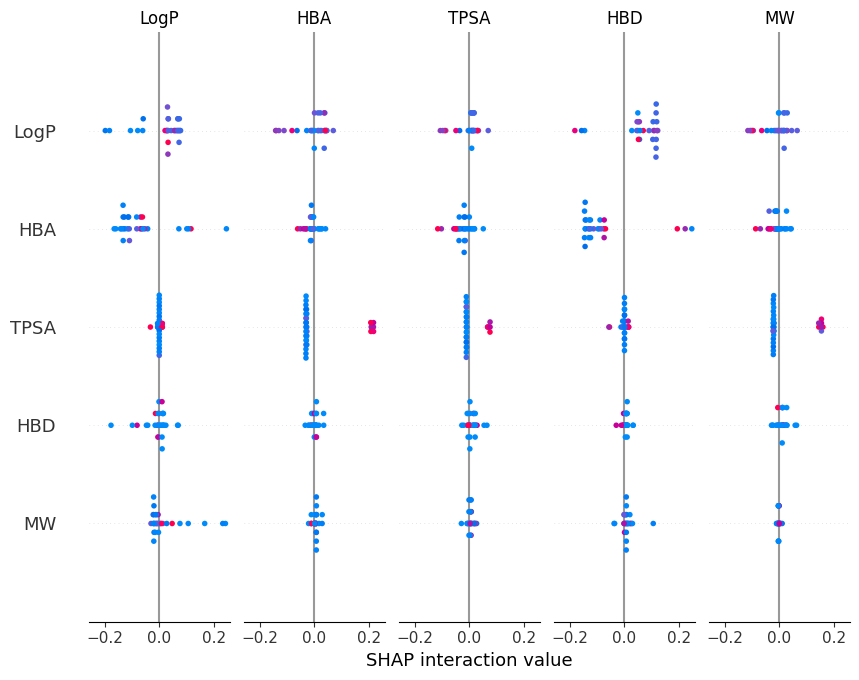

SHAP analysis encountered an error: operands could not be broadcast together with shapes (25,) (5,) (25,) 
Continuing with permutation importance results only.


In [56]:
# Try SHAP with KernelExplainer - more computationally expensive but more robust
try:
    print("\nCalculating SHAP values using KernelExplainer (this may take some time)...")
    # Use a very small sample as KernelExplainer is computationally expensive
    sample_size = min(30, X_test.shape[0])  
    X_sample = X_test.iloc[:sample_size]
    
    # Create background data (smaller for speed)
    X_background = shap.kmeans(X_train, 10)
    
    # Create the explainer
    def model_predict(X):
        return model.predict_proba(X)
    
    explainer = shap.KernelExplainer(model_predict, X_background)
    
    # Calculate SHAP values for each class
    shap_values = explainer.shap_values(X_sample)
    
    # Plot summary for all classes
    plt.figure(figsize=(12, 10))
    shap.summary_plot(shap_values, X_sample, plot_type="bar", class_names=[f"Cluster {i}" for i in range(num_clusters)])
    plt.title("Feature Importance Based on SHAP Values (All Classes)")
    plt.tight_layout()
    plt.savefig("shap_importance_all_classes.png", dpi=300)
    plt.close()
    
    # Create a combined importance score across all classes
    all_importance = np.zeros(X.shape[1])
    for i in range(num_clusters):
        all_importance += np.abs(shap_values[i]).mean(axis=0)
    
    # Create DataFrame and save to CSV
    shap_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'SHAP_Importance': all_importance
    }).sort_values('SHAP_Importance', ascending=False)
    
    print("\nTop 20 Most Important Features (SHAP):")
    print(shap_importance_df.head(20))
    shap_importance_df.to_csv("descriptor_importance_shap.csv", index=False)
    
    # Plot individual class importance for top 5 features
    top_features = shap_importance_df['Feature'].head(5).tolist()
    
    # Create per-class importance heatmap
    feature_importance_by_class = np.zeros((len(top_features), num_clusters))
    
    for i, feature in enumerate(top_features):
        feature_idx = list(X.columns).index(feature)
        for j in range(num_clusters):
            feature_importance_by_class[i, j] = np.abs(shap_values[j][:, feature_idx]).mean()
    
    # Create heatmap
    plt.figure(figsize=(12, 8))
    sns.heatmap(
        feature_importance_by_class, 
        annot=True, 
        cmap="YlGnBu", 
        xticklabels=[f"Cluster {i}" for i in range(num_clusters)],
        yticklabels=top_features
    )
    plt.title("Top Features Importance by Cluster (SHAP)")
    plt.tight_layout()
    plt.savefig("feature_importance_by_cluster_shap.png", dpi=300)
    plt.close()
    
except Exception as e:
    print(f"SHAP analysis encountered an error: {str(e)}")
    print("Continuing with permutation importance results only.")


<Figure size 1000x1200 with 0 Axes>

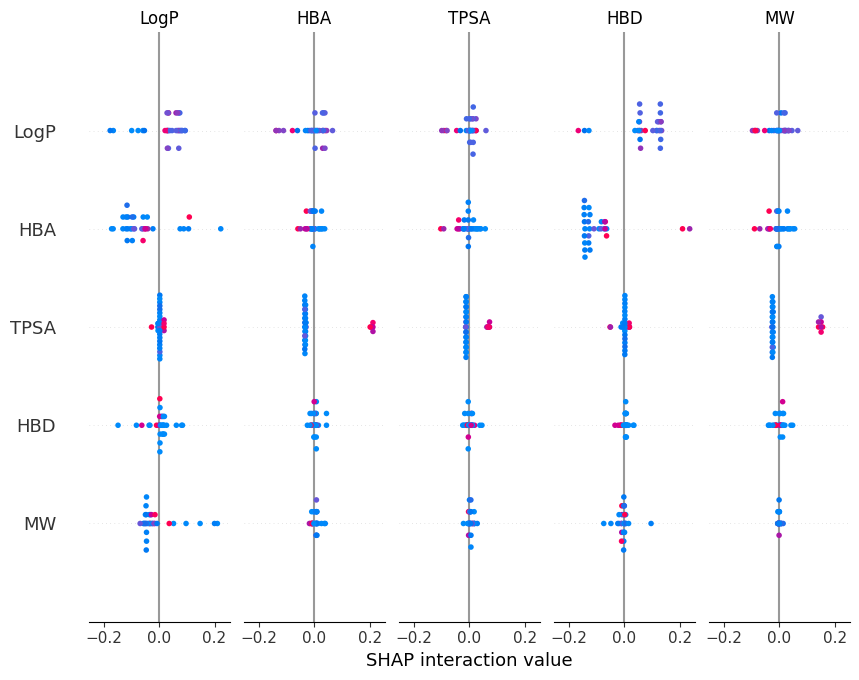

In [47]:
# Create summary plots
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, X_test, plot_type="bar", class_names=model.classes_)
plt.title("Feature Importance Based on SHAP Values (All Classes)")
plt.tight_layout()
plt.savefig("shap_importance_all_classes.png", dpi=300)
plt.close()

<Figure size 1000x1200 with 0 Axes>

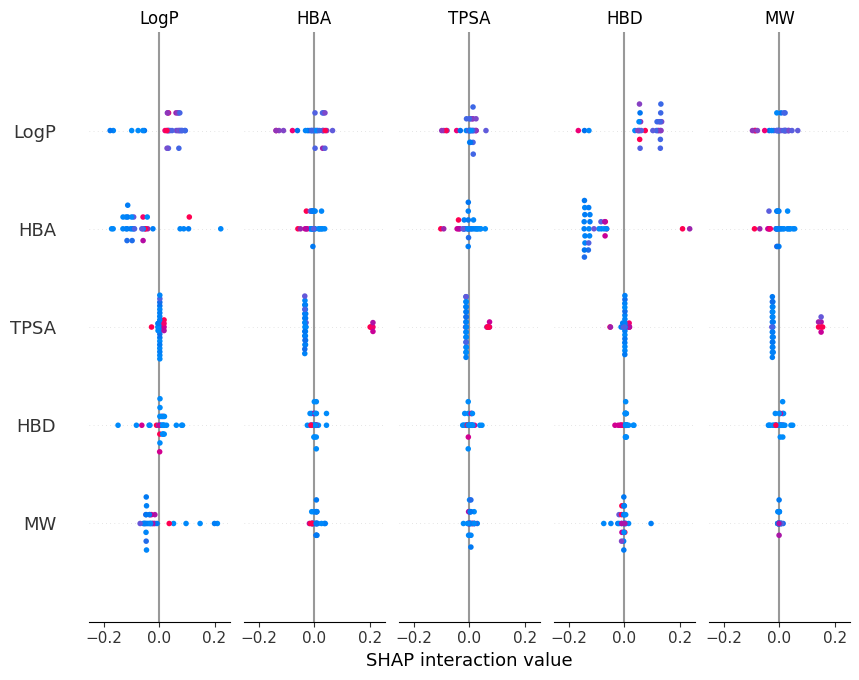

In [51]:
# Create overall feature importance plot
plt.figure(figsize=(10, 12))
shap.summary_plot(shap_values, X_sample, plot_type="bar", class_names=[f"Cluster {i}" for i in range(num_clusters)])
plt.title("Feature Importance Based on SHAP Values (All Classes)")
plt.tight_layout()
# plt.savefig("shap_importance_all_classes.png", dpi=300)
plt.close()

In [52]:
# Plot SHAP values for each class individually - correctly handling the dimensions
for i in range(num_clusters):
    plt.figure(figsize=(12, 8))
    # Make sure we're passing the right dimensions to the summary plot
    class_shap_values = shap_values[i]
    shap.summary_plot(class_shap_values, X_sample, plot_type="bar")
    plt.title(f"Feature Importance for Cluster {i}")
    plt.tight_layout()
    # plt.savefig(f"shap_importance_cluster_{i}.png", dpi=300)
    plt.close()

AssertionError: The shape of the shap_values matrix does not match the shape of the provided data matrix.

<Figure size 1200x800 with 0 Axes>

<-- ------------------------------------------------------------------------------------------------------ -->

Ramdon forest

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap
import os
import datetime

# Load your dataset
descriptor_path = "../DATA/molecular_descriptors_concat_data_product2_Target-cmc.csv"
df_descriptors = pd.read_csv(descriptor_path)
cluster_path = "../RESULTS/2025-03-06_12-55-55-cmc/cluster_labels.csv"
df_cluster = pd.read_csv(cluster_path)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_path = f"../RESULTS/shap/rf2/{timestamp}"
os.makedirs(output_path, exist_ok=True)
print(f"Created directory: {output_path}")

X = df_descriptors.drop(columns=['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES'])
y = df_cluster['Cluster Labels']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

# Get number of clusters
num_clusters = len(np.unique(y))
print(f"Number of clusters: {num_clusters}")

# Use Permutation Feature Importance - reliable and fast
result = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10, 
    random_state=42
)

# Get the importance scores
importance = result.importances_mean
sorted_idx = np.argsort(importance)[::-1]

# Create a DataFrame of the feature importances
perm_importance_df = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance': importance[sorted_idx]
})

# Print the top 20 features
print("\nTop 20 Most Important Features (Permutation Importance):")
print(perm_importance_df.head(20))

# Save to CSV
perm_importance_df.to_csv(f"{output_path}/descriptor_importance_permutation.csv", index=False)

# Plot the top 15 features with highest at top
plt.figure(figsize=(10, 8))
n_features = min(15, len(perm_importance_df))
features_to_plot = perm_importance_df.head(n_features).copy()  # Get top n features
features_to_plot = features_to_plot.iloc[::-1]  # Reverse for plot (highest at top)

plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Features (Permutation Importance)')
plt.tight_layout()
plt.savefig(f"{output_path}/permutation_importance.png", dpi=300)
plt.close()

# Skip SHAP analysis for now and use the model's built-in feature importances
print("\nUsing Random Forest's built-in feature importance...")

# Get feature importance from the Random Forest model
rf_importance = model.feature_importances_
rf_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_importance
})
rf_importance_df = rf_importance_df.sort_values('Importance', ascending=False)

# Print the top 20 features
print("\nTop 20 Most Important Features (Random Forest Built-in):")
print(rf_importance_df.head(20))

# Save to CSV
rf_importance_df.to_csv(f"{output_path}/rf_importance.csv", index=False)

# Plot the top 15 features with highest at top
plt.figure(figsize=(10, 8))
n_features = min(15, len(rf_importance_df))
features_to_plot = rf_importance_df.head(n_features).copy()
features_to_plot = features_to_plot.iloc[::-1]  # Reverse for plotting

plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features (Random Forest Built-in)')
plt.tight_layout()
plt.savefig(f"{output_path}/rf_importance.png", dpi=300)
plt.close()

# Try a more direct approach for cluster-specific importance
print("\nCalculating cluster-specific feature importance...")

# Store importance by cluster
cluster_importance = []

# For each cluster, train a dedicated Random Forest
for i in range(num_clusters):
    print(f"Analyzing cluster {i}...")
    
    # Create binary target (this cluster vs the rest)
    y_train_binary = (y_train == i).astype(int)
    y_test_binary = (y_test == i).astype(int)
    
    # Train a Random Forest
    cluster_model = RandomForestClassifier(n_estimators=100, random_state=42)
    cluster_model.fit(X_train, y_train_binary)
    
    # Get feature importance
    importance = cluster_model.feature_importances_
    
    # Store importance
    cluster_importance.append(importance)
    
    # Create feature importance DataFrame for this cluster
    cluster_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    # Save to CSV
    cluster_importance_df.to_csv(f"{output_path}/cluster_{i}_importance.csv", index=False)
    
    # Plot top 10 features for this cluster
    plt.figure(figsize=(10, 6))
    top_n = min(10, len(cluster_importance_df))
    features_to_plot = cluster_importance_df.head(top_n).copy()
    features_to_plot = features_to_plot.iloc[::-1]  # Reverse for plotting
    
    plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
    plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top Features for Cluster {i}')
    plt.tight_layout()
    plt.savefig(f"{output_path}/cluster_{i}_importance.png", dpi=300)
    plt.close()

# Create a heatmap showing feature importance by cluster
print("\nCreating feature importance heatmap by cluster...")

# Get top N features across all clusters
top_n_features = 10
all_top_features = set()

for i in range(num_clusters):
    cluster_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': cluster_importance[i]
    }).sort_values('Importance', ascending=False)
    
    top_features = cluster_importance_df.head(top_n_features)['Feature'].tolist()
    all_top_features.update(top_features)

# Convert to list and get the most important ones
all_top_features = list(all_top_features)
if len(all_top_features) > 15:  # Limit to top 15 overall for readability
    # Calculate overall importance
    overall_importance = np.zeros(len(X.columns))
    for imp in cluster_importance:
        overall_importance += imp
        
    # Create DataFrame with overall importance
    overall_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': overall_importance
    }).sort_values('Importance', ascending=False)
    
    # Get top 15 features
    all_top_features = overall_df.head(15)['Feature'].tolist()

# Create importance matrix for heatmap
importance_matrix = np.zeros((len(all_top_features), num_clusters))

for i in range(num_clusters):
    for j, feature in enumerate(all_top_features):
        feature_idx = list(X.columns).index(feature)
        importance_matrix[j, i] = cluster_importance[i][feature_idx]

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    importance_matrix,
    annot=True,
    cmap="YlGnBu",
    xticklabels=[f"Cluster {i}" for i in range(num_clusters)],
    yticklabels=all_top_features
)
plt.title("Feature Importance by Cluster")
plt.tight_layout()
plt.savefig(f"{output_path}/feature_importance_by_cluster.png", dpi=300)
plt.close()

print("\nAnalysis completed. Check the output directory for visualizations and CSV files.")

Created directory: ../RESULTS/shap/rf2/2025-03-06_21-02-31
Model Accuracy: 0.9375
Number of clusters: 5

Top 20 Most Important Features (Permutation Importance):
                  Feature  Importance
0                     HBD    0.053125
1                    LogP    0.034375
2         NumChargedAtoms    0.031250
3            FractionCSP3    0.031250
4                   NumOH    0.006250
5   LongestAliphaticChain    0.003125
6             CarbonCount    0.000000
7                    TPSA    0.000000
8                     HBA    0.000000
9                RotBonds    0.000000
10           NumAromRings    0.000000
11               NumRings    0.000000
12         HeavyAtomCount    0.000000
13                  Chi1v    0.000000
14   AliphaticCarbonCount    0.000000
15                  Chi0v    0.000000
16           NumCarbonyls    0.000000
17           NumCarboxyls    0.000000
18              NumEthers    0.000000
19             NumSulfurs    0.000000

Using Random Forest's built-in feature 

xgboost

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import shap
import xgboost as xgb
import os
import datetime


# Load your dataset
descriptor_path = "../DATA/molecular_descriptors_concat_data_product2_Target-cmc.csv"
df_descriptors = pd.read_csv(descriptor_path)
cluster_path = "../RESULTS/2025-03-06_12-55-55-cmc/cluster_labels.csv"
df_cluster = pd.read_csv(cluster_path)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_path = f"../RESULTS/shap/xgb2/{timestamp}"
os.makedirs(output_path, exist_ok=True)
print(f"Created directory: {output_path}")

X = df_descriptors.drop(columns=['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES'])
y = df_cluster['Cluster Labels']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get number of clusters
num_clusters = len(np.unique(y))
print(f"Number of clusters: {num_clusters}")

# Fix XGBoost initialization
if num_clusters > 2:
    objective = 'multi:softmax'
    num_classes = num_clusters
else:
    objective = 'binary:logistic'
    num_classes = 2

# Train model
model = xgb.XGBClassifier(
    objective=objective, 
    num_class=num_classes if num_clusters > 2 else None,
    n_estimators=100, 
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

# Use Permutation Feature Importance - reliable and fast
result = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10, 
    random_state=42
)

# Get the importance scores
importance = result.importances_mean
sorted_idx = np.argsort(importance)[::-1]  # Sort in descending order

# Create a DataFrame of the feature importances
perm_importance_df = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance': importance[sorted_idx]
})

# Print the top 20 features
print("\nTop 20 Most Important Features (Permutation Importance):")
print(perm_importance_df.head(20))

# Save to CSV
perm_importance_df.to_csv(f"{output_path}/descriptor_importance_permutation.csv", index=False)

# Plot the top 15 features with highest at top
plt.figure(figsize=(10, 8))
n_features = 15
features_to_plot = perm_importance_df.head(n_features)  # Get top n features
features_to_plot = features_to_plot.iloc[::-1]  # Reverse for plot (highest at top)

plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Features (Permutation Importance)')
plt.tight_layout()
plt.savefig(f"{output_path}/permutation_importance.png", dpi=300)
plt.close()

Created directory: ../RESULTS/shap/xgb2/2025-03-06_20-46-27
Number of clusters: 5
Model Accuracy: 0.9688

Top 20 Most Important Features (Permutation Importance):
                 Feature  Importance
0                     MW    0.303125
1           FractionCSP3    0.181250
2                    HBD    0.168750
3                   LogP    0.046875
4             PolarRatio    0.006250
5        NumChargedAtoms    0.003125
6            CarbonCount    0.000000
7                   TPSA    0.000000
8                    HBA    0.000000
9               RotBonds    0.000000
10          NumAromRings    0.000000
11              NumRings    0.000000
12        HeavyAtomCount    0.000000
13                 Chi1v    0.000000
14  AliphaticCarbonCount    0.000000
15                 Chi0v    0.000000
16          NumCarbonyls    0.000000
17          NumCarboxyls    0.000000
18             NumEthers    0.000000
19            NumSulfurs    0.000000


In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
import os
import datetime

# Load your dataset
descriptor_path = "../DATA/molecular_descriptors_concat_data_product2_Target-cmc.csv"
df_descriptors = pd.read_csv(descriptor_path)
cluster_path = "../RESULTS/2025-03-06_12-55-55-cmc/cluster_labels.csv"
df_cluster = pd.read_csv(cluster_path)

timestamp = datetime.datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
output_path = f"../RESULTS/shap/xgb2/{timestamp}"
os.makedirs(output_path, exist_ok=True)
print(f"Created directory: {output_path}")

X = df_descriptors.drop(columns=['Name', 'TARGET', 'Log(cmc*1000+1)', 'SMILES'])
y = df_cluster['Cluster Labels']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get number of clusters
num_clusters = len(np.unique(y))
print(f"Number of clusters: {num_clusters}")

# Configure XGBoost for multiclass classification
if num_clusters > 2:
    objective = 'multi:softmax'
    num_classes = num_clusters
else:
    objective = 'binary:logistic'
    num_classes = 2

# Train a model
model = xgb.XGBClassifier(
    objective=objective,
    num_class=num_classes if num_clusters > 2 else None,
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

# Evaluate the model
accuracy = model.score(X_test, y_test)
print(f"Model Accuracy: {accuracy:.4f}")

# Use Permutation Feature Importance - reliable and fast
result = permutation_importance(
    model, X_test, y_test, 
    n_repeats=10, 
    random_state=42
)

# Get the importance scores
importance = result.importances_mean
sorted_idx = np.argsort(importance)[::-1]

# Create a DataFrame of the feature importances
perm_importance_df = pd.DataFrame({
    'Feature': X.columns[sorted_idx],
    'Importance': importance[sorted_idx]
})

# Print the top 20 features
print("\nTop 20 Most Important Features (Permutation Importance):")
print(perm_importance_df.head(20))

# Save to CSV
perm_importance_df.to_csv(f"{output_path}/descriptor_importance_permutation.csv", index=False)

# Plot the top 15 features with highest at top
plt.figure(figsize=(10, 8))
n_features = min(15, len(perm_importance_df))
features_to_plot = perm_importance_df.head(n_features).copy()  # Get top n features
features_to_plot = features_to_plot.iloc[::-1]  # Reverse for plot (highest at top)

plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
plt.xlabel('Permutation Importance')
plt.title('Top 15 Features (Permutation Importance)')
plt.tight_layout()
plt.savefig(f"{output_path}/permutation_importance.png", dpi=300)
plt.close()

# Use XGBoost's built-in feature importances
print("\nUsing XGBoost's built-in feature importance...")

# Get feature importance from the XGBoost model
xgb_importance = model.feature_importances_
xgb_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb_importance
})
xgb_importance_df = xgb_importance_df.sort_values('Importance', ascending=False)

# Print the top 20 features
print("\nTop 20 Most Important Features (XGBoost Built-in):")
print(xgb_importance_df.head(20))

# Save to CSV
xgb_importance_df.to_csv(f"{output_path}/xgb_importance.csv", index=False)

# Plot the top 15 features with highest at top
plt.figure(figsize=(10, 8))
n_features = min(15, len(xgb_importance_df))
features_to_plot = xgb_importance_df.head(n_features).copy()
features_to_plot = features_to_plot.iloc[::-1]  # Reverse for plotting

plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
plt.xlabel('Feature Importance')
plt.title('Top 15 Features (XGBoost Built-in)')
plt.tight_layout()
plt.savefig(f"{output_path}/xgb_importance.png", dpi=300)
plt.close()

# Try a more direct approach for cluster-specific importance
print("\nCalculating cluster-specific feature importance...")

# Store importance by cluster
cluster_importance = []

# For each cluster, train a dedicated XGBoost classifier
for i in range(num_clusters):
    print(f"Analyzing cluster {i}...")
    
    # Create binary target (this cluster vs the rest)
    y_train_binary = (y_train == i).astype(int)
    y_test_binary = (y_test == i).astype(int)
    
    # Train an XGBoost model
    cluster_model = xgb.XGBClassifier(
        objective='binary:logistic',  # Binary classification for one-vs-rest
        n_estimators=100,
        random_state=42
    )
    cluster_model.fit(X_train, y_train_binary)
    
    # Get feature importance
    importance = cluster_model.feature_importances_
    
    # Store importance
    cluster_importance.append(importance)
    
    # Create feature importance DataFrame for this cluster
    cluster_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': importance
    }).sort_values('Importance', ascending=False)
    
    # Save to CSV
    cluster_importance_df.to_csv(f"{output_path}/cluster_{i}_importance.csv", index=False)
    
    # Plot top 10 features for this cluster
    plt.figure(figsize=(10, 6))
    top_n = min(10, len(cluster_importance_df))
    features_to_plot = cluster_importance_df.head(top_n).copy()
    features_to_plot = features_to_plot.iloc[::-1]  # Reverse for plotting
    
    plt.barh(range(len(features_to_plot)), features_to_plot['Importance'])
    plt.yticks(range(len(features_to_plot)), features_to_plot['Feature'])
    plt.xlabel('Feature Importance')
    plt.title(f'Top Features for Cluster {i}')
    plt.tight_layout()
    plt.savefig(f"{output_path}/cluster_{i}_importance.png", dpi=300)
    plt.close()

# Create a heatmap showing feature importance by cluster
print("\nCreating feature importance heatmap by cluster...")

# Get top N features across all clusters
top_n_features = 10
all_top_features = set()

for i in range(num_clusters):
    cluster_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': cluster_importance[i]
    }).sort_values('Importance', ascending=False)
    
    top_features = cluster_importance_df.head(top_n_features)['Feature'].tolist()
    all_top_features.update(top_features)

# Convert to list and get the most important ones
all_top_features = list(all_top_features)
if len(all_top_features) > 15:  # Limit to top 15 overall for readability
    # Calculate overall importance
    overall_importance = np.zeros(len(X.columns))
    for imp in cluster_importance:
        overall_importance += imp
        
    # Create DataFrame with overall importance
    overall_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': overall_importance
    }).sort_values('Importance', ascending=False)
    
    # Get top 15 features
    all_top_features = overall_df.head(15)['Feature'].tolist()

# Create importance matrix for heatmap
importance_matrix = np.zeros((len(all_top_features), num_clusters))

for i in range(num_clusters):
    for j, feature in enumerate(all_top_features):
        feature_idx = list(X.columns).index(feature)
        importance_matrix[j, i] = cluster_importance[i][feature_idx]

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    importance_matrix,
    annot=True,
    cmap="YlGnBu",
    xticklabels=[f"Cluster {i}" for i in range(num_clusters)],
    yticklabels=all_top_features
)
plt.title("Feature Importance by Cluster")
plt.tight_layout()
plt.savefig(f"{output_path}/feature_importance_by_cluster.png", dpi=300)
plt.close()

# Optionally: Create a normalized importance heatmap
# This helps see the relative importance within each cluster
normalized_importance = importance_matrix.copy()
for i in range(num_clusters):
    if np.sum(normalized_importance[:, i]) > 0:
        normalized_importance[:, i] = normalized_importance[:, i] / np.sum(normalized_importance[:, i])

plt.figure(figsize=(12, 10))
sns.heatmap(
    normalized_importance,
    annot=True,
    cmap="YlGnBu",
    xticklabels=[f"Cluster {i}" for i in range(num_clusters)],
    yticklabels=all_top_features,
    fmt=".3f"
)
plt.title("Normalized Feature Importance by Cluster")
plt.tight_layout()
plt.savefig(f"{output_path}/normalized_feature_importance_by_cluster.png", dpi=300)
plt.close()

print("\nAnalysis completed. Check the output directory for visualizations and CSV files.")

Created directory: ../RESULTS/shap/xgb2/2025-03-06_21-18-27
Number of clusters: 5
Model Accuracy: 0.9688

Top 20 Most Important Features (Permutation Importance):
                 Feature  Importance
0                     MW    0.303125
1           FractionCSP3    0.181250
2                    HBD    0.168750
3                   LogP    0.046875
4             PolarRatio    0.006250
5        NumChargedAtoms    0.003125
6            CarbonCount    0.000000
7                   TPSA    0.000000
8                    HBA    0.000000
9               RotBonds    0.000000
10          NumAromRings    0.000000
11              NumRings    0.000000
12        HeavyAtomCount    0.000000
13                 Chi1v    0.000000
14  AliphaticCarbonCount    0.000000
15                 Chi0v    0.000000
16          NumCarbonyls    0.000000
17          NumCarboxyls    0.000000
18             NumEthers    0.000000
19            NumSulfurs    0.000000

Using XGBoost's built-in feature importance...

Top 20 Most